## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Classic Model**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 0$  
$\lambda_{bin} = 0$

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('../')

In [4]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (15,15)
model_name = 'Classic'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'Classic Model'

th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name) 

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.0747 ± 0.0001
val_loss: 0.0770 ± 0.0004


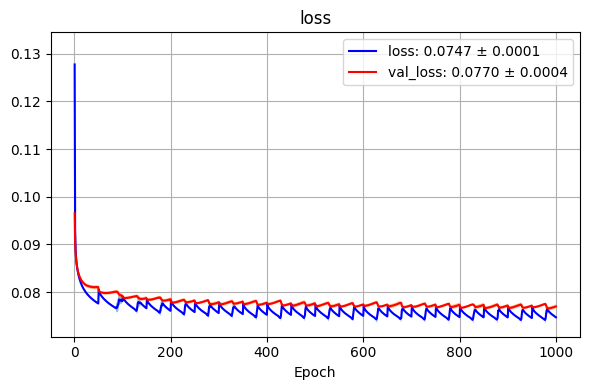

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

Threshold: 0.3971 ± 0.0013


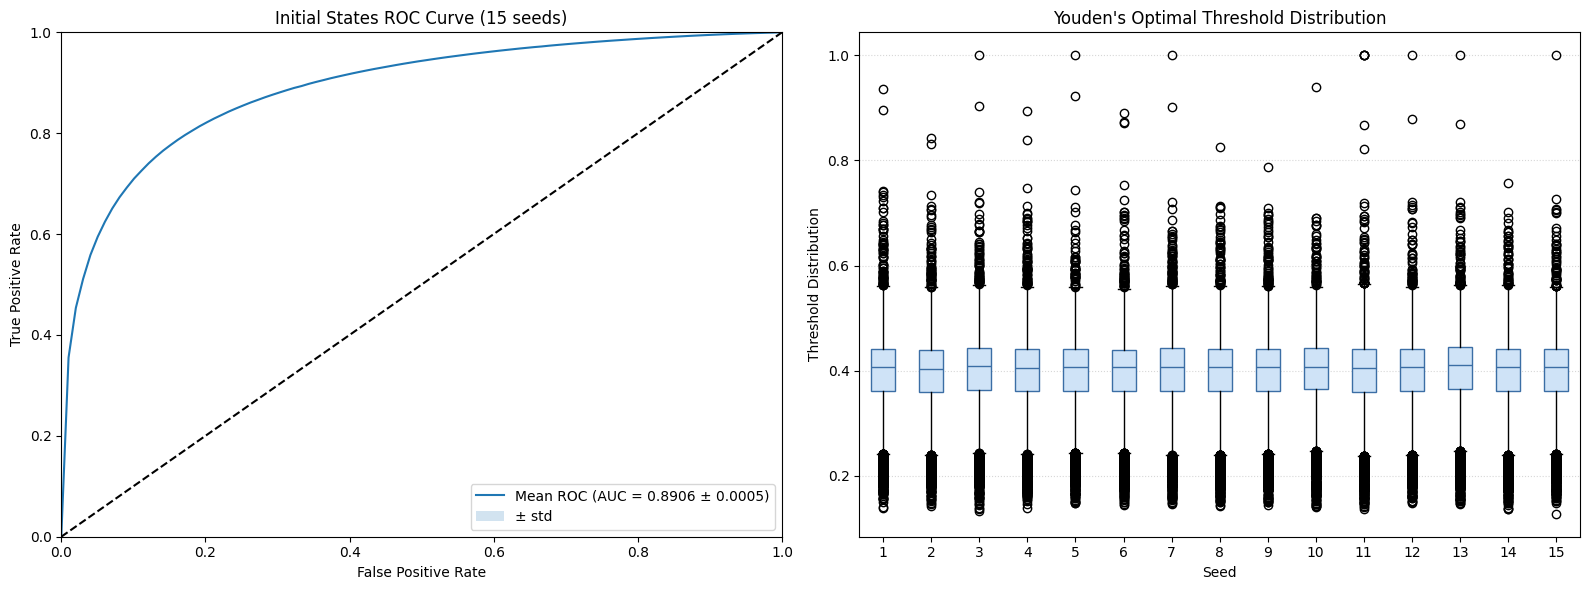

In [5]:
threshold, all_board_thresholds = eval_tools.computeROC(predictions_paths, test_data, 'init', shape)

In [6]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8592 ± 0.0005
Accuracy_fin: 0.7801 ± 0.0004
Recall_init: 0.5971 ± 0.0041
Recall_fin: 0.0019 ± 0.0002
Specificity_init: 0.9348 ± 0.0010
Specificity_fin: 0.9996 ± 0.0000
Precision_init: 0.7255 ± 0.0020
Precision_fin: 0.5965 ± 0.0270
F1Score_init: 0.6550 ± 0.0019
F1Score_fin: 0.0038 ± 0.0005


--- Results Initial States (15 seeds) ---
Density (true): 22.39% ± 9.39%
Density (pred): 32.22% ± 8.38%
Error/seed:     9.83% ± 0.08%
Max value predicted: 0.9972
HUC% (0.45, 0.55): 12.31% ± 0.10%
HUC% (0.4, 0.6): 23.98% ± 0.20%
HUC% (0.35, 0.65): 35.13% ± 0.27%
Fuzziness Index: 0.7471 ± 0.1483
MSE (prob):0.1214 ± 0.0542
MSE (bin):0.1799 ± 0.1116
MSE (all-zero): 0.2239 ± 0.0939
Wasserstein (EMD): 2.0215 ± 0.0071


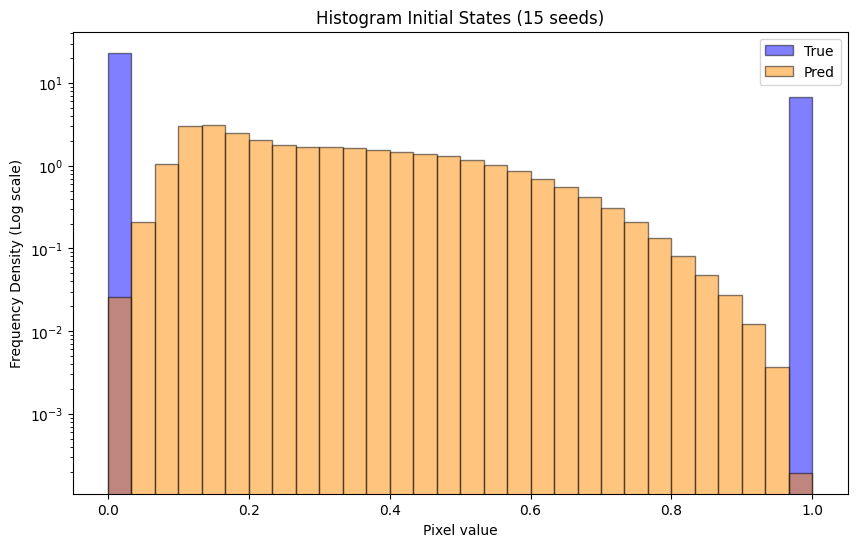

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 22.00% ± 9.81%
Density (pred): 2.14% ± 0.86%
Error/seed:     19.86% ± 0.06%
Max value predicted: 0.9655
HUC% (0.45, 0.55): 0.09% ± 0.01%
HUC% (0.4, 0.6): 0.21% ± 0.01%
HUC% (0.35, 0.65): 0.42% ± 0.02%
Fuzziness Index: 0.0696 ± 0.0285
MSE (prob):0.2078 ± 0.1007
MSE (bin):0.2202 ± 0.0991
MSE (all-zero): 0.2200 ± 0.0981
Wasserstein (EMD): 2.8374 ± 0.0346


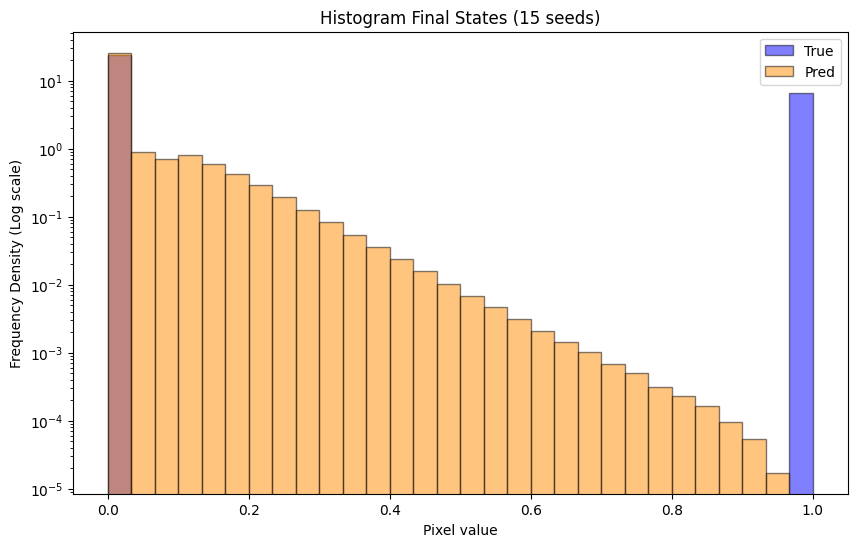

In [8]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

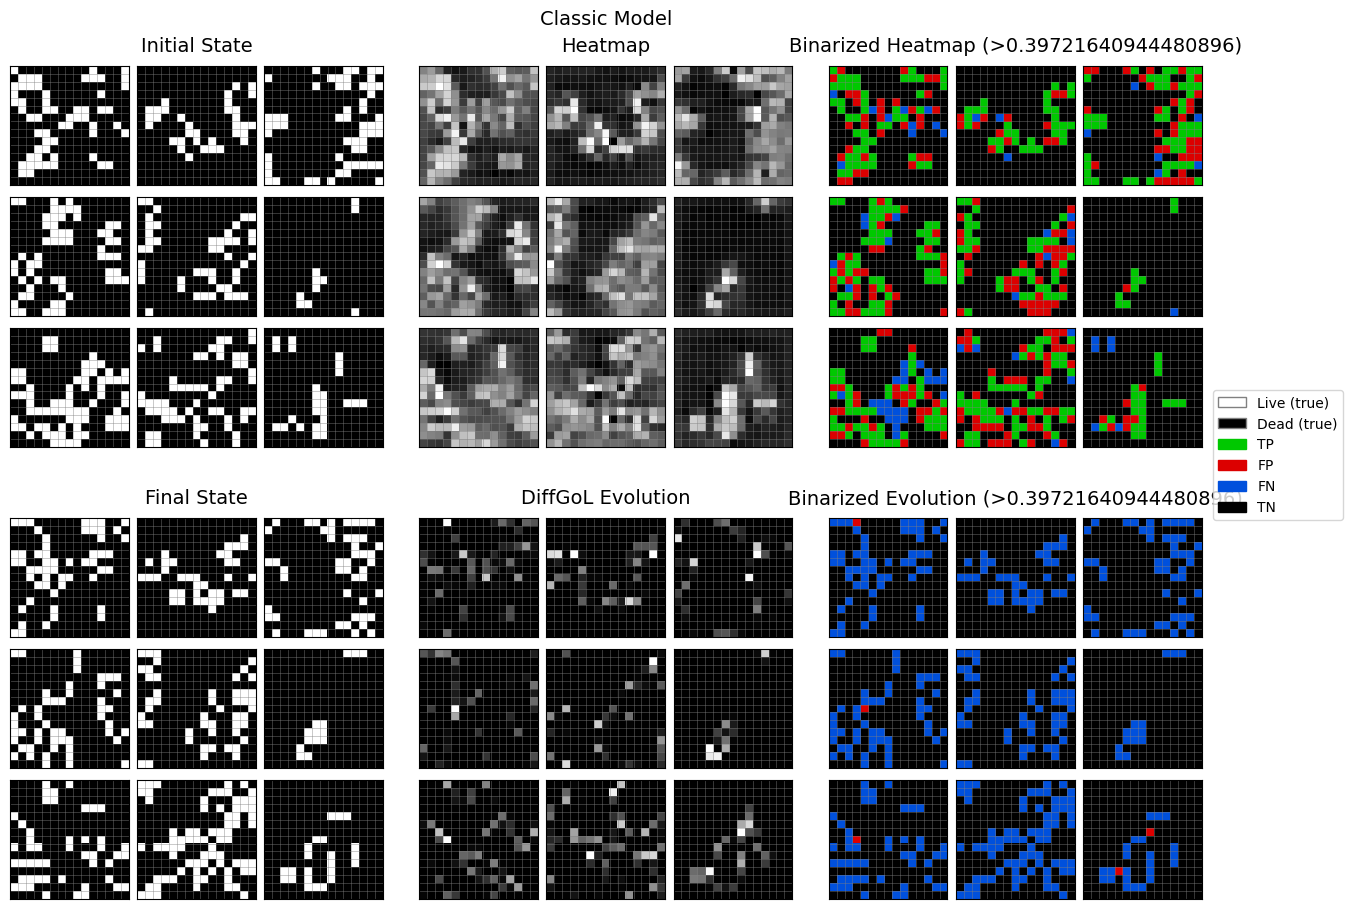

In [9]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)